In [14]:
import requests
import re
import cv2
import numpy as np
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display

In [15]:
def _to_gray(img):
    arr = np.array(img)
    if arr.ndim == 2:
        return arr.astype(np.uint8)
    if arr.shape[2] == 4:                       # RGBA -> buang kanal alpha
        arr = cv2.cvtColor(arr, cv2.COLOR_RGBA2RGB)
    return cv2.cvtColor(arr, cv2.COLOR_RGB2GRAY)


In [16]:
def hist(groy):
    gray = np.array(groy)
    src = gray.astype(np.uint8)
    hist = np.bincount(src.ravel(), minlength=256).astype(np.float64)
    cdf = np.cumsum(hist)
    cdf_min = cdf[cdf > 0].min()
    total = src.size
    if total - cdf_min <= 0:                    # citra seragam
        return src.copy()
    lut = np.round((cdf - cdf_min) / (total - cdf_min) * 255.0)
    lut = np.clip(lut, 0, 255).astype(np.uint8)
    return lut[src]

In [17]:
def negative(img):
    img_np = np.array(img)
    if len(img_np.shape) == 3:
        out = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    else:
        out = img_np.copy()
    L = 256
    out = (L - 1) - out
    return out

In [18]:
def log(img):
    img_np = np.array(img)
    if len(img_np.shape) == 3:
        img_np = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    out = img_np.astype(float)
    R_max = np.max(out)
    L = 256
    c = (L - 1) / np.log(1 + R_max) if R_max > 0 else 1
    out = c * np.log(1 + out)
    return np.clip(out, 0, 255).astype(np.uint8)


In [19]:
def gamma(img, gamma=0.4, grayscale=False):
    arr = np.array(img)
    if grayscale:
        arr = _to_gray(arr)
    out = arr.astype(np.float32)
    R_max = float(out.max())
    L = 256
    if R_max <= 0:
        return np.zeros(out.shape, dtype=np.uint8)
    c = (L - 1) / (R_max ** gamma)
    out = c * np.power(out, gamma)
    return np.clip(out, 0, 255).astype(np.uint8)

In [20]:
def stretch(img, a=0, b=255, grayscale=False):
    arr = np.array(img)
    if grayscale:
        arr = _to_gray(arr)
    out = arr.astype(np.float32)
    rmin, rmax = float(out.min()), float(out.max())
    if rmax == rmin:                            # citra seragam -> peregangan tidak terdefinisi
        return arr.astype(np.uint8)
    out = (b - a) * (out - rmin) / (rmax - rmin) + a
    return np.clip(out, 0, 255).astype(np.uint8)

In [21]:
def gaussian_kernel(size=3, sigma=0.5):
  k = size // 2
  kernel = np.zeros((size,size), dtype = np.float32)

  for x in range(-k, k+1):
    for y in range(-k, k+1):
      kernel[x+k, y+k] = np.exp(-(x**2 + y**2) / (2 * sigma**2))
  kernel /= (2 * np.pi * sigma ** 2)
  return kernel / np.sum(kernel)

def gauss(image):
  img = np.array(image)
  kernel = gaussian_kernel()
  blurred = cv2.filter2D(img, -1, kernel) # Blur Image

  return np.clip(blurred, 0, 255).astype(np.uint8)

In [22]:
def grey(image, low, high):
  img = np.array(image)
  if len(img.shape) == 3:
    img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
  out = img.copy().astype(float)
  for i in range(out.shape[0]):
    for j in range(out.shape[1]):
      if (low <= img[i, j] <= high):
        out[i, j] = 255
      else:
        out[i, j] = 0
  return out.astype(np.uint8)

In [23]:
def smooth(img):
    arr = np.array(img).astype(np.float32)
    kernel = np.ones((3, 3), np.float32) / 9.0
    blurred = cv2.filter2D(arr, -1, kernel)
    return np.clip(blurred, 0, 255).astype(np.uint8)

In [24]:
def avg(img, amount=0.7):
    arr = np.array(img).astype(np.float32)
    kernel = np.ones((3, 3), np.float32) / 9.0
    blurred = cv2.filter2D(arr, -1, kernel)
    sharpened = arr + amount * (arr - blurred)
    return np.clip(sharpened, 0, 255).astype(np.uint8)

In [25]:
def lap(image):
  img = np.array(image)
  lap_kernel = np.array([[-1, -1, -1],
                     [-1, 8, -1],
                     [-1, -1, -1]], dtype=np.float32)
  lap = cv2.filter2D(img.astype(np.float32), cv2.CV_32F, lap_kernel)
  sharpened = img.astype(np.float32) + 0.2 * lap

  return np.clip(sharpened, 0, 255).astype(np.uint8)

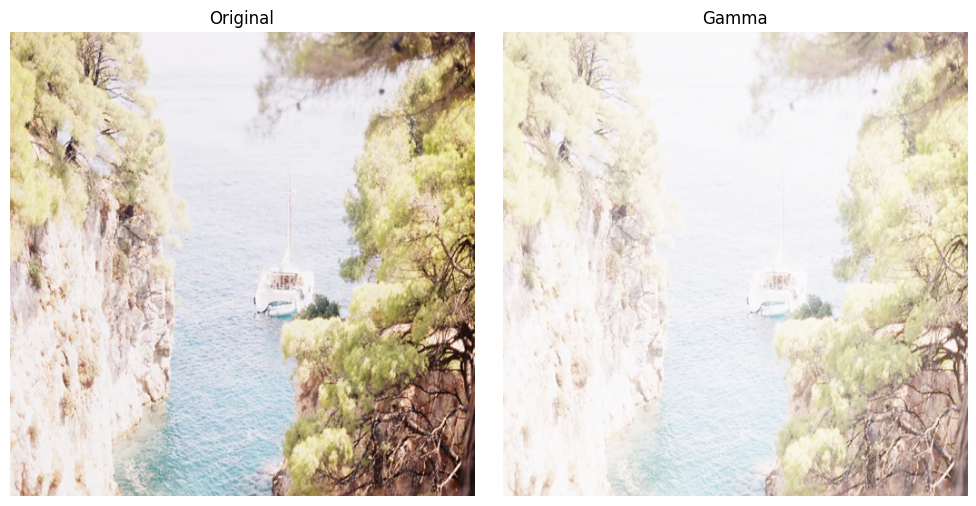

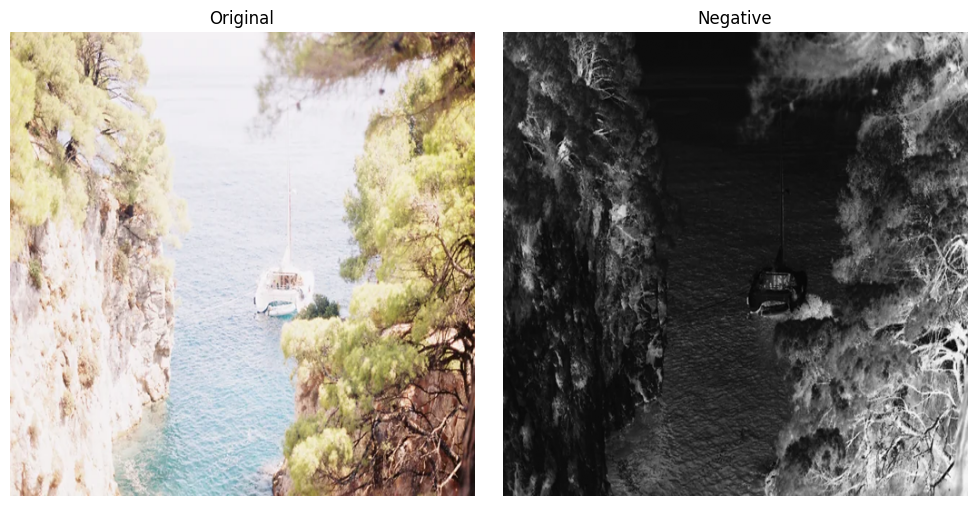

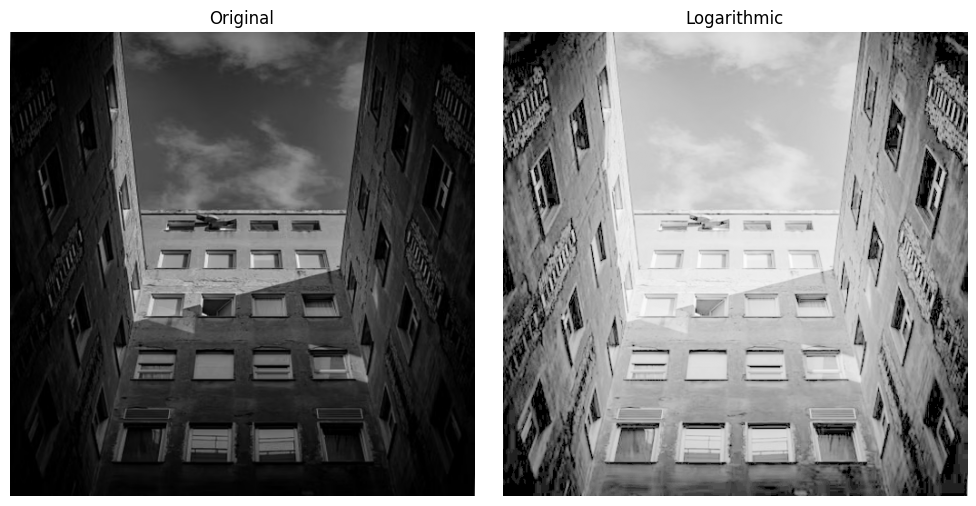

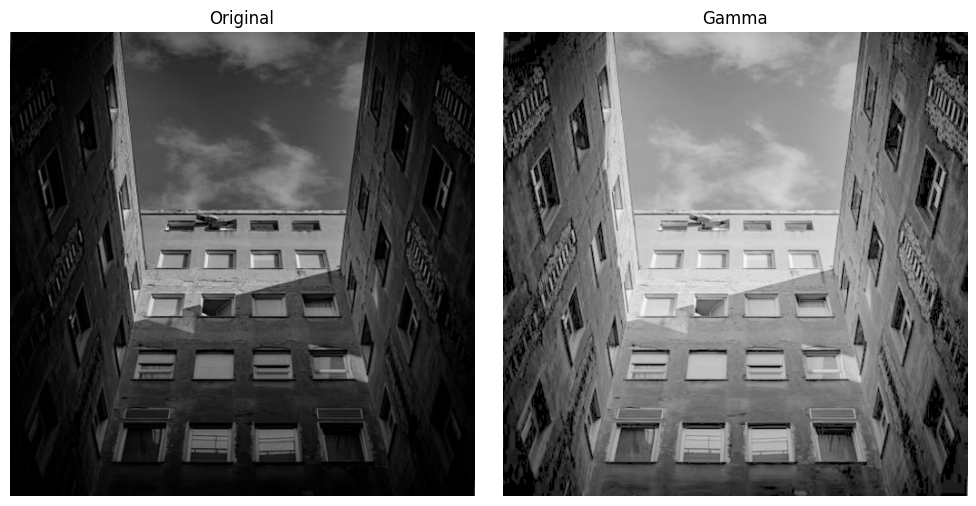

Citra dalam kondisi normal, tidak memerlukan penyesuaian.


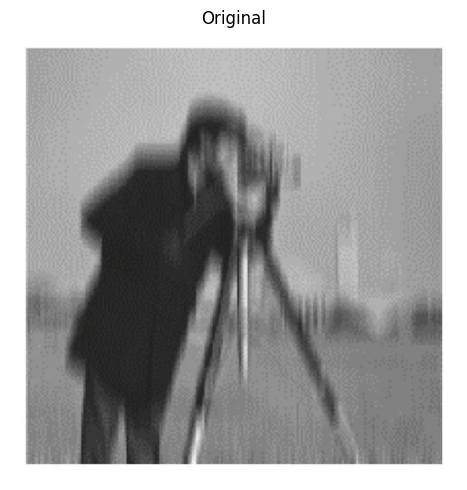

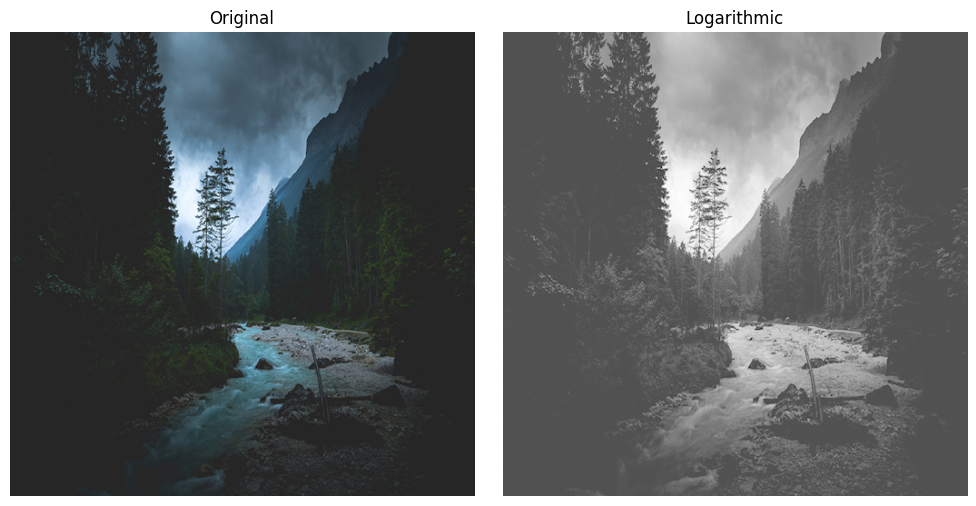

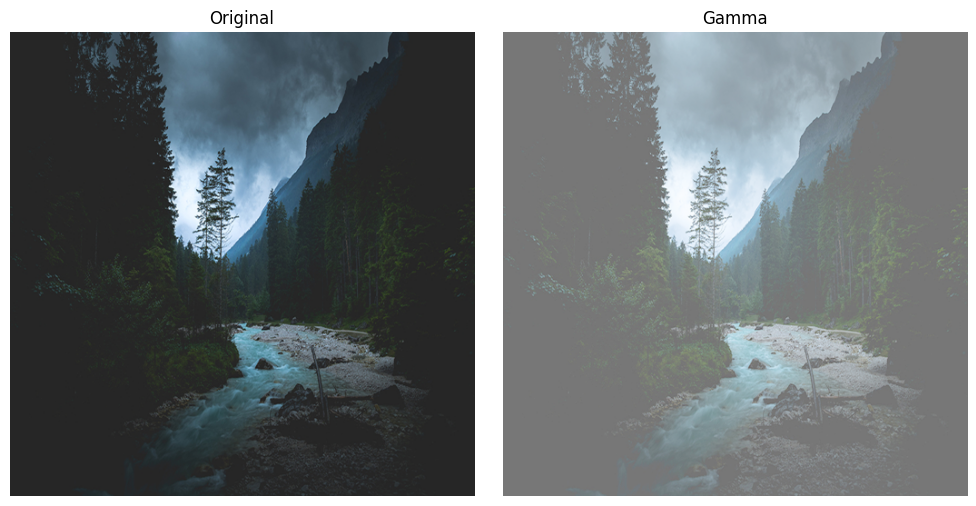

Citra dalam kondisi normal, tidak memerlukan penyesuaian.


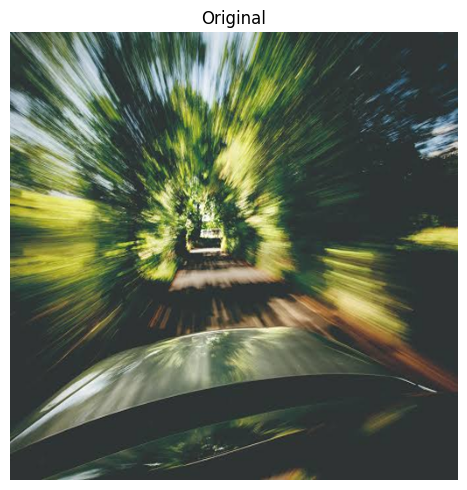

Citra dalam kondisi normal, tidak memerlukan penyesuaian.


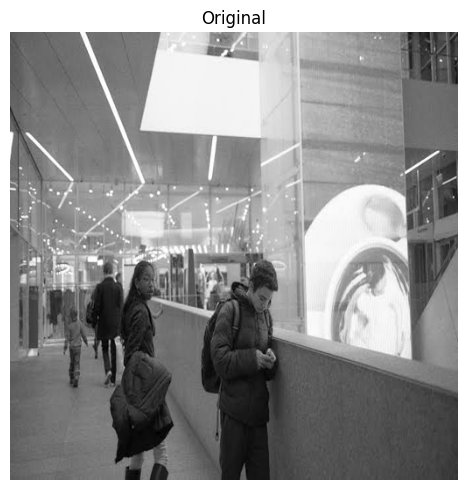

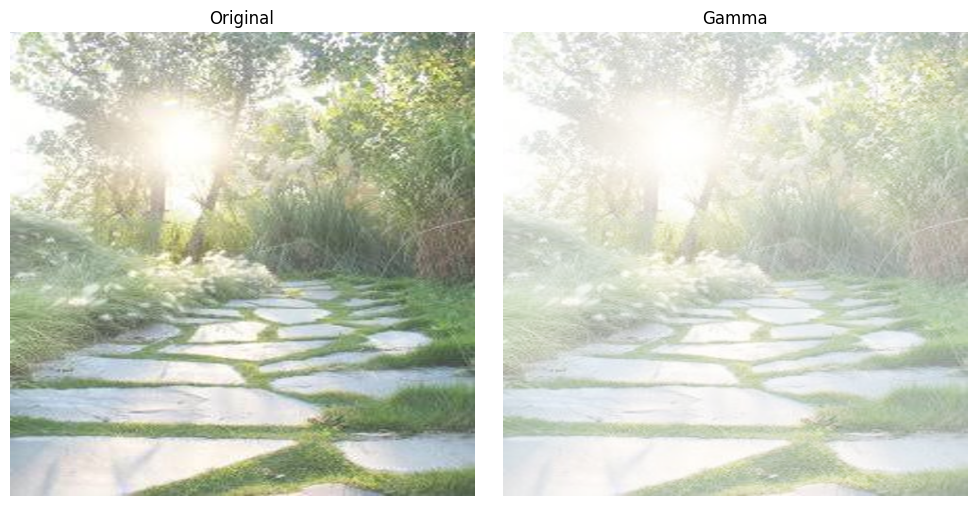

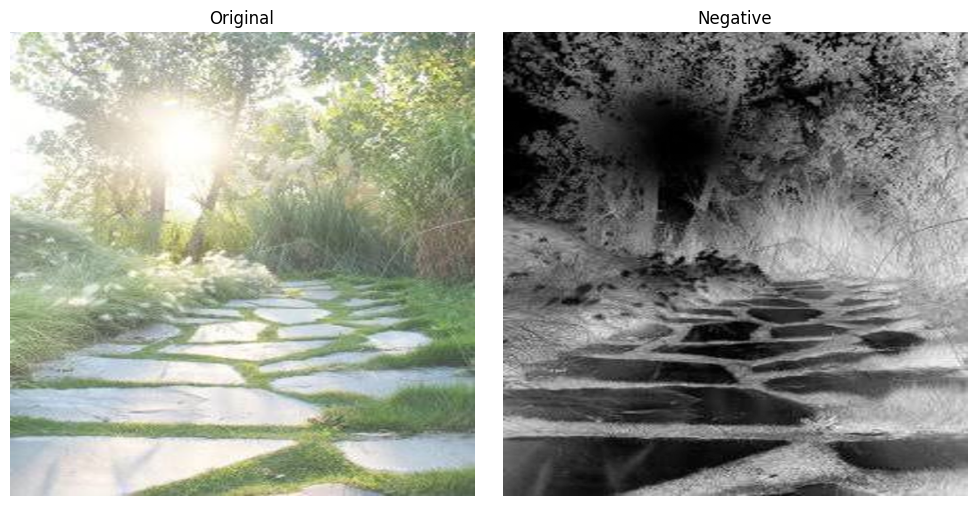

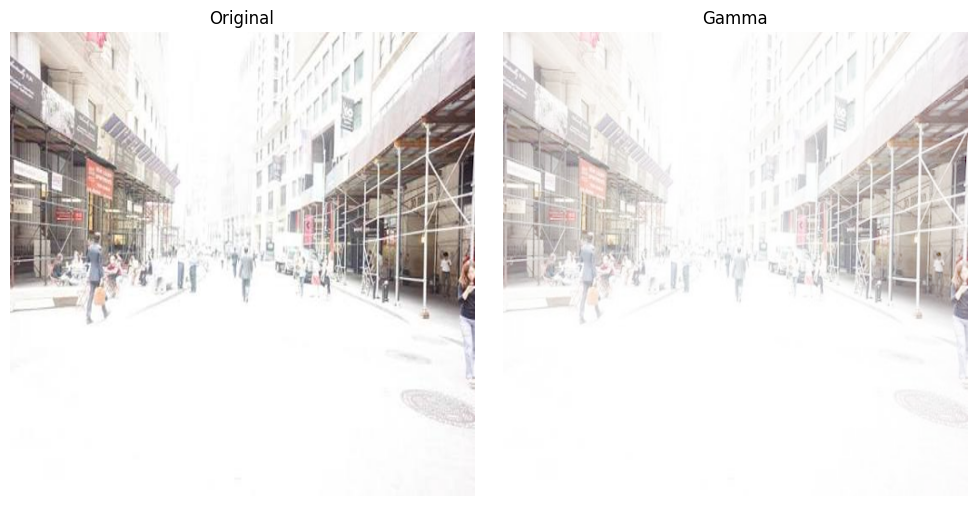

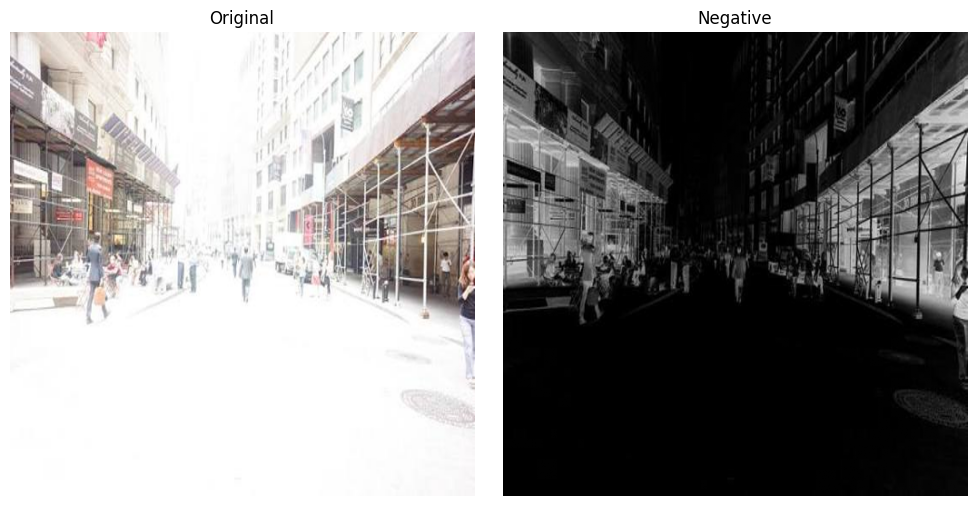

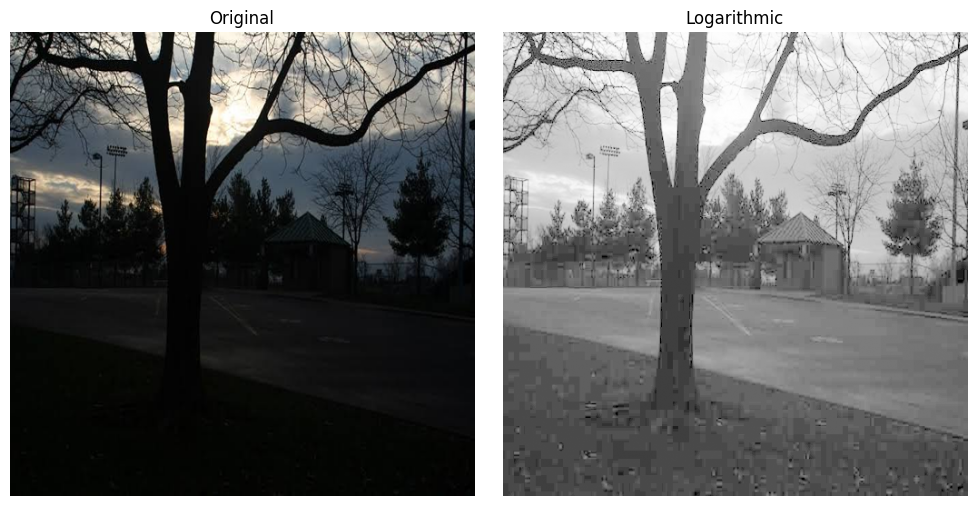

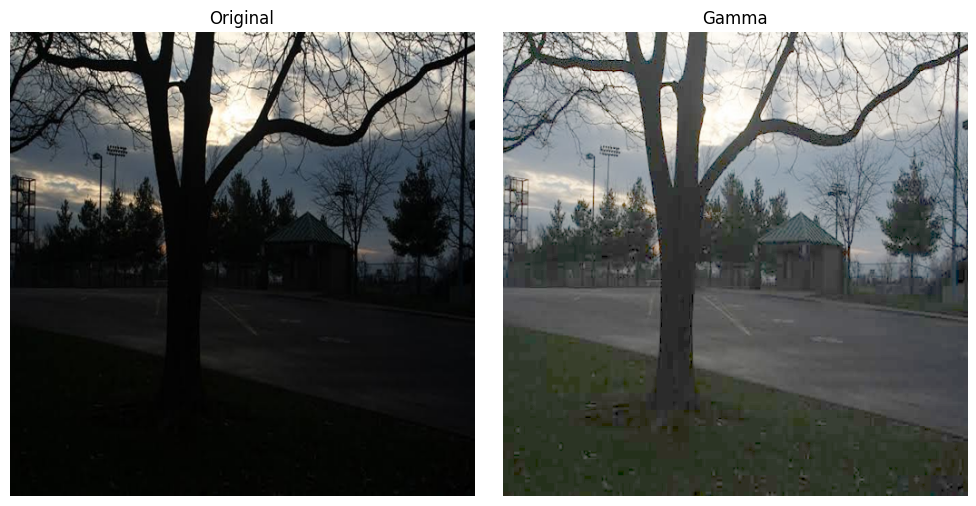

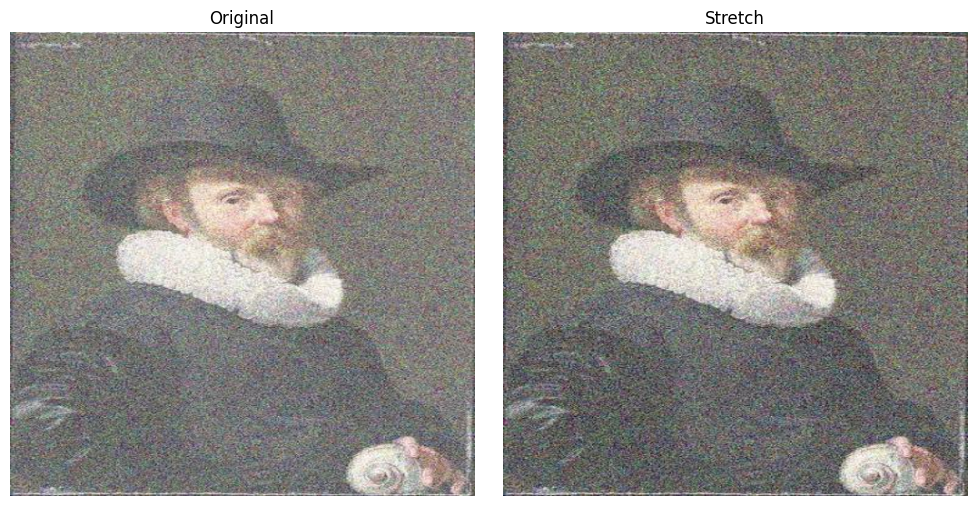

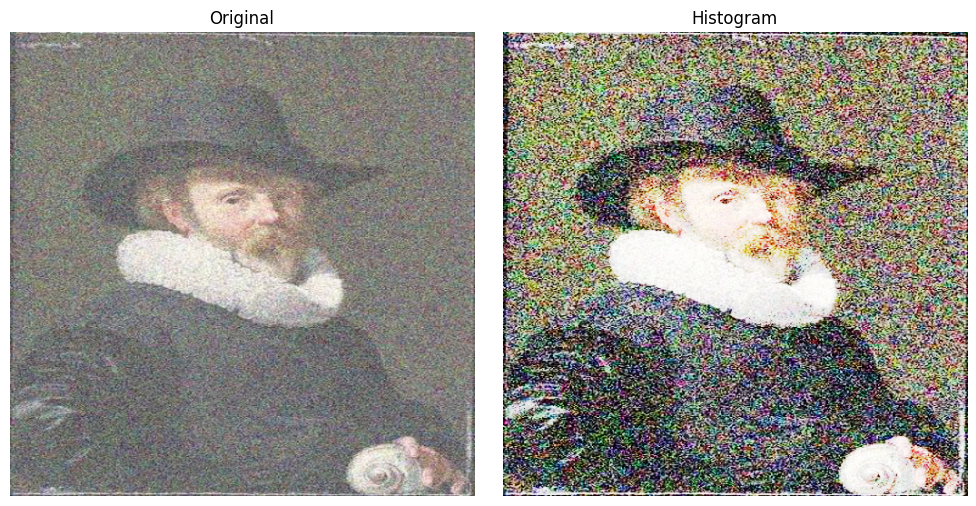

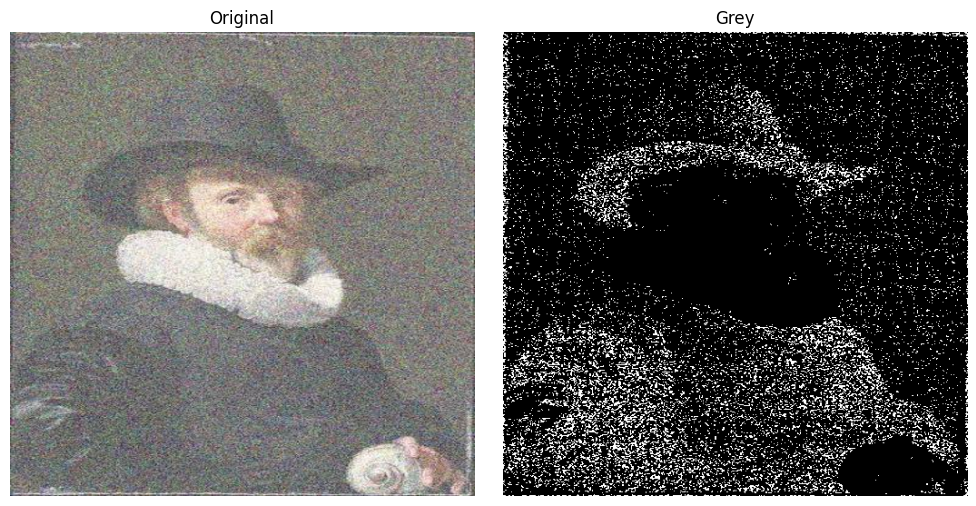

Citra dalam kondisi normal, tidak memerlukan penyesuaian.


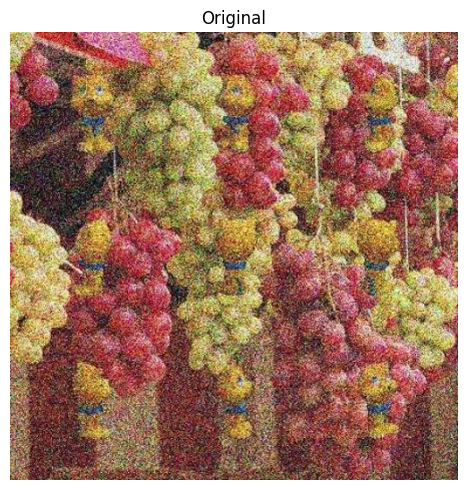

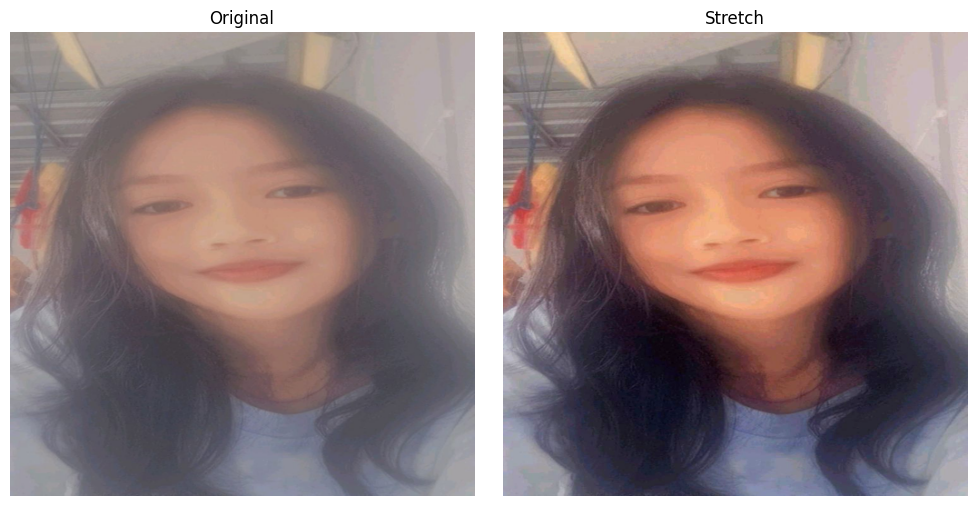

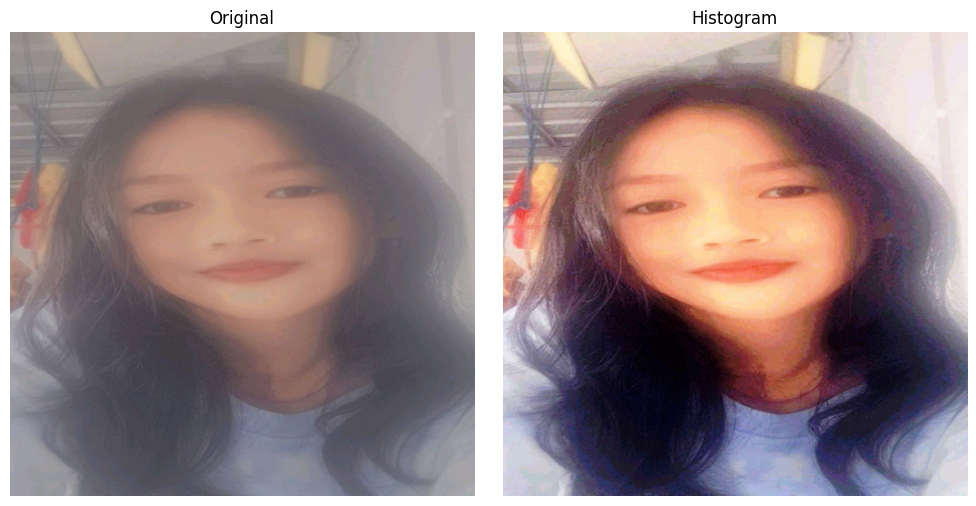

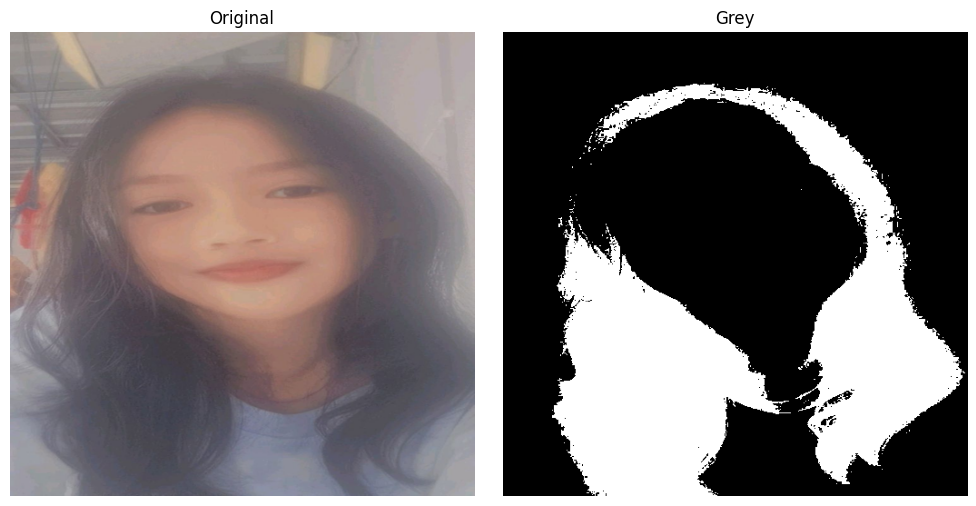

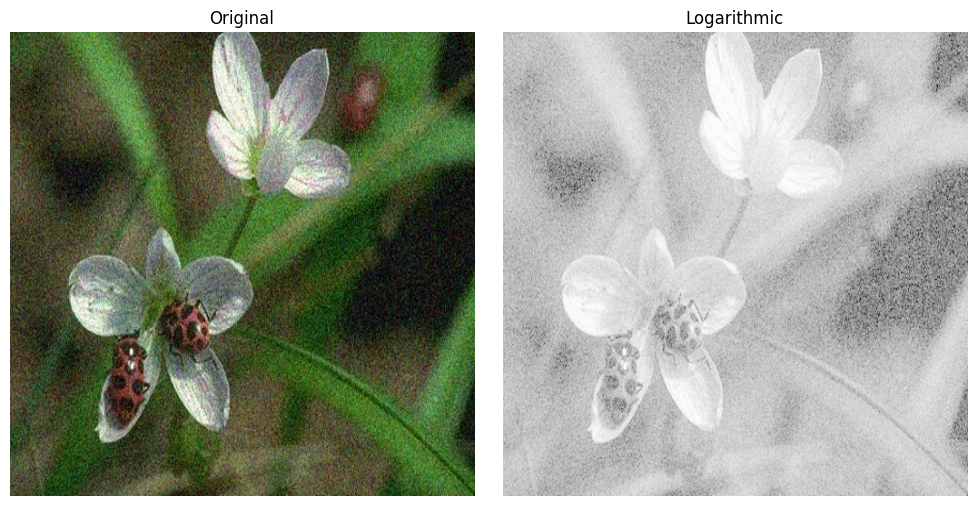

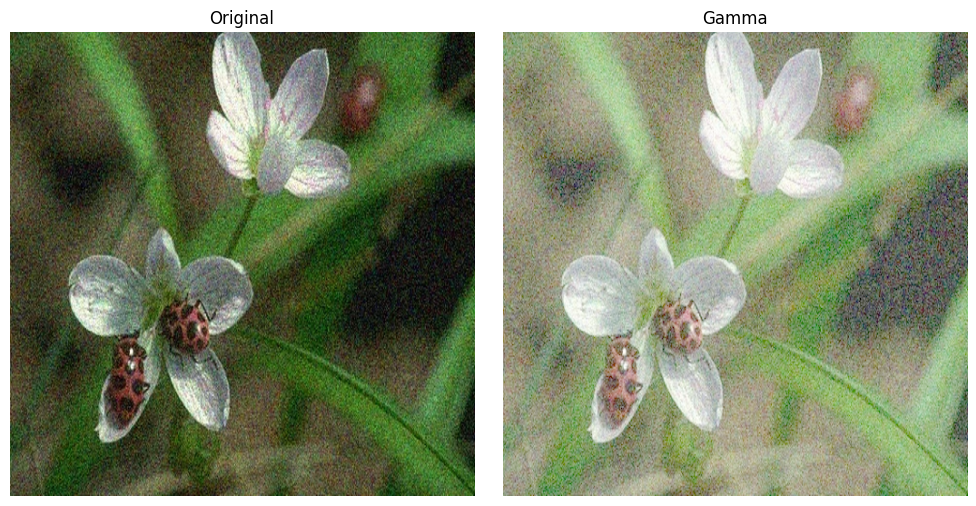

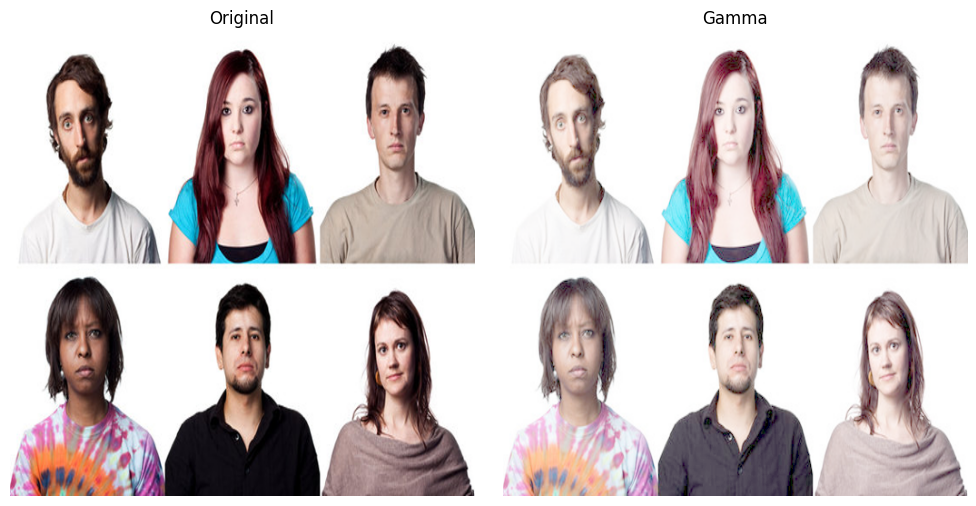

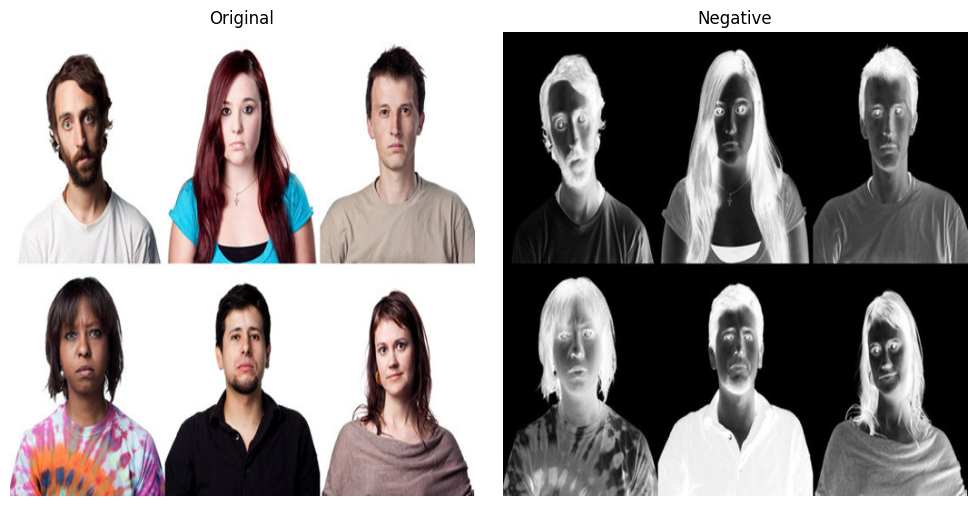

In [26]:
images = [
    'https://drive.google.com/file/d/1tPloWEDnmtXOkjQQGhvvL-2hdvMzaLxN/view?usp=drive_link',
    'https://drive.google.com/file/d/1VGoo4B-5WXzrGATLU6WgdjOk0z8RvV1c/view?usp=drive_link',
    'https://drive.google.com/file/d/1be44JQ_hoEZp_EnB1XiabKAHA6fdx0JO/view?usp=drive_link',
    'https://drive.google.com/file/d/1WrScoURcxkg4oFcUA9MC-iHpRa03mPrx/view?usp=drive_link',
    'https://drive.google.com/file/d/1FYHkilUVqxaVRvL9LxiuWvW_iEfTn99n/view?usp=drive_link',
    'https://drive.google.com/file/d/1qhiBUyjOazw5TpIE_WrFeCxv2cPu6vXP/view?usp=drive_link',
    'https://drive.google.com/file/d/1Gj9vmdkbo_TZGc5FgXA2wQhHENaYOwI6/view?usp=drive_link',
    'https://drive.google.com/file/d/1RX0YCMEkwYKxN3xQiwwN9CfS1BWko2mv/view?usp=drive_link',
    'https://drive.google.com/file/d/1oWhmfuyI36tZo0N8ZQ9O_uaS9r7_eIIc/view?usp=drive_link',
    'https://drive.google.com/file/d/1hyQzXHjBoWbTbKRNEnoLb83kqDM2Z9Qv/view?usp=drive_link',
    'https://drive.google.com/file/d/1Y-ZIBTYVyojQRiH4EGtIZLuJYP6CVtGA/view?usp=drive_link',
    'https://drive.google.com/file/d/1tgCOszbTBVCycvGmcFurQxTuumzp5AuN/view?usp=drive_link',
    'https://drive.google.com/file/d/16zTGDGQm0WWMe_uTMkZQfxnp6upQ9aND/view?usp=drive_link',
    'https://drive.google.com/file/d/1o4Ns9n_4yQoeVJQC6oU5hWmv11q2i-F2/view?usp=drive_link'
]


def display_results(img, results, titles):
    if not isinstance(results, list):
        results = [results]
    if not isinstance(titles, list):
        titles = ["Original", titles]
    images = [img] + results
    plt.figure(figsize=(10, 5))
    for i, (image, title) in enumerate(zip(images, titles), 1):
        plt.subplot(1, len(images), i)
        image_np = np.array(image)
        if len(image_np.shape) == 2:
            plt.imshow(image_np, cmap="gray")
        else:
            plt.imshow(image_np)
        plt.title(title)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

def classify_image(img):
    gray = _to_gray(img)
    mean = float(gray.mean())
    std = float(gray.std())
    lap_var = float(cv2.Laplacian(gray, cv2.CV_64F).var())

    if mean < 85:
        label = "gelap"
    elif mean > 170:
        label = "terang"
    elif std < 45:
        label = "kontras rendah"
    elif lap_var < 100:
        label = "buram"
    else:
        label = "normal"

    return label

def eksperiment(image):
    labels = classify_image(image)
    match labels:
      case 'noise':
        display_results(image, [smooth(image)], ['Original', 'Smooth'])
        display_results(image, [gauss(image)], ['Original', 'Gaussian'])
        display_results(image, [avg(image)], ['Original', 'Average'])
      case 'gelap':
        display_results(image, [log(image)], ["Original", "Logarithmic"])
        display_results(image, [gamma(image)], ["Original", "Gamma"])
      case 'terang':
        display_results(image, [gamma(image)], ["Original", "Gamma"])
        display_results(image, [negative(image)], ["Original", "Negative"])
      case 'kontras rendah':
        display_results(image, [stretch(image)], ['Original', 'Stretch'])
        display_results(image, [hist(image)], ['Original', 'Histogram'])
        display_results(image, [grey(image, 0, 100)], ['Original', 'Grey'])
      case 'buram':
         display_results(image,[smooth(image)],['Original','Smooth'])
         display_results(image, [gauss(image)], ['Original', 'Gaussian'])
         display_results(image, [avg(image)], ['Original', 'Average'])
      case 'normal':
        print("Citra dalam kondisi normal, tidak memerlukan penyesuaian.")
        display_results(image, [], ["Original"])
def resize(src, size=(512, 512)):
    file_id = re.search(r"/d/([^/]+)", src).group(1)

    download_url = f"https://drive.google.com/uc?export=download&id={file_id}"

    response = requests.get(download_url)
    response.raise_for_status()

    image = Image.open(BytesIO(response.content))
    image = image.resize(size)

    return image
for src in images:
    image = resize(src)
    eksperiment(image)